# LSN-0.2 — Statistics I: Distributions, Sampling, Variance

| | |
|---|---|
| **Lesson** | `LSN-0.2` — Module `MOD-0` (Foundations), Week 1 |
| **Serves** | `OUT-0.3` — *reason about distributions, sampling, and variance well enough to ask "how reliable is this answer, on what data?"* |
| **Duration** | 90 min session (20 + 25 + 20 + 25) + 30 min pre-work |
| **Verified by** | `ASM-0` — scenario questions, not definitions |
| **Lesson plan** | `program/lessons/LSN-0.2-statistics-1-distributions-sampling-variance.md` |

**The misconception this session kills:** that a single number — a mean, an accuracy score — tells you
something on its own. It doesn't. It hides a **distribution**, a **sample size**, and a **collection
method**, and any of the three can make the number a lie.

**How to run this notebook.** Launch Jupyter from the repo root with the `LSN-0.1` venv active, then
`Run → Run All Cells`. It runs top to bottom with no arguments and no network; every number you see below
is computed from seeded data, so your output matches the room's.

```
source .venv/bin/activate
jupyter notebook notebooks/lessons/LSN-0.2_Statistics_1_Distributions_Sampling_Variance.ipynb
```

**Order of business:**

1. **Pre-work — before the session** (~10 min of the 30): run the two-distribution cell below and bring the plot.
2. **Session** — four segments, in order, matching the lesson plan: distributions (20) → sampling (25) →
   variance & outliers (20) → the "92% accurate" client drill (25).
3. **Homework** — 32 fixed-bid projects: compute, plot, interpret, and write two sentences. Saves to
   `outputs/lsn-0.2/` and feeds `ASM-0`.

Fill-in cells never crash the notebook — they tell you what's still missing and wait for you.

## Setup — imports, palette, seeds

Three rules this notebook obeys, so that your numbers and the numbers on the projector agree:

- **Everything is seeded.** Each demo makes its own generator with its own seed, so you can re-run any single
  cell in any order and get the same picture back.
- **Every chart uses the VSP palette** and drops its top/right spines — house style, and it makes the
  screenshots reusable in a client deck.
- **Core stack only** (`numpy`, `pandas`, `matplotlib`, `seaborn`). Nothing heavier is installed until Week 2.

In [1]:
# numpy (arrays, distributions, percentiles)
import numpy as np
# pandas (small tables we can read at a glance)
import pandas as pd
# matplotlib (every chart in this notebook)
import matplotlib.pyplot as plt
# seaborn (box/violin summaries — first used here, per LSN-0.1 Checkpoint 2)
import seaborn as sns
# stdlib pathlib (locate the repo root without hardcoding a path)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for
# --- reference lines, bar edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      — primary series
    "green":  "#65a74e",  # green           — second series
    "yellow": "#ffe86b",  # yellow          — highlight (always with a dark edge)
    "mint":   "#97f377",  # green-lightest  — third series
    "ink":    "#2b374d",  # navy-darkest    — lines, edges, text
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found — are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())

print(f"numpy {np.__version__} · pandas {pd.__version__} · seaborn {sns.__version__}")
print(f"Repo root : {REPO_ROOT}")
print("[PASS] Setup complete — core stack only, palette loaded, paths resolved.")

numpy 2.5.1 · pandas 3.0.5 · seaborn 0.13.2
Repo root : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
[PASS] Setup complete — core stack only, palette loaded, paths resolved.


---

# Pre-work — run this **before** the session

*30 minutes total. No pre-work, no seat.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | Watch **StatQuest with Josh Starmer** — *["Histograms, Clearly Explained"](https://www.youtube.com/watch?v=qBigTkBLU6g)* and *["The Main Ideas behind Probability Distributions"](https://www.youtube.com/watch?v=oI3hZJqXJuc)* (`youtube.com/@statquest`) | 20 min | One written sentence: **what does a histogram tell you that the mean alone cannot?** |
| 2 | Run the cell below (this is the ~10-line notebook from the lesson plan) and look at what comes out | 10 min | **The executed plot** — same mean, wildly different spread |

Task 2 in one sentence: draw 10,000 samples from `normal(mean=50, sd=2)` and 10,000 from
`normal(mean=50, sd=20)`, then plot both histograms overlaid. Both distributions have **the same mean**.
Before you run it, predict what the two shapes will look like — then check yourself.

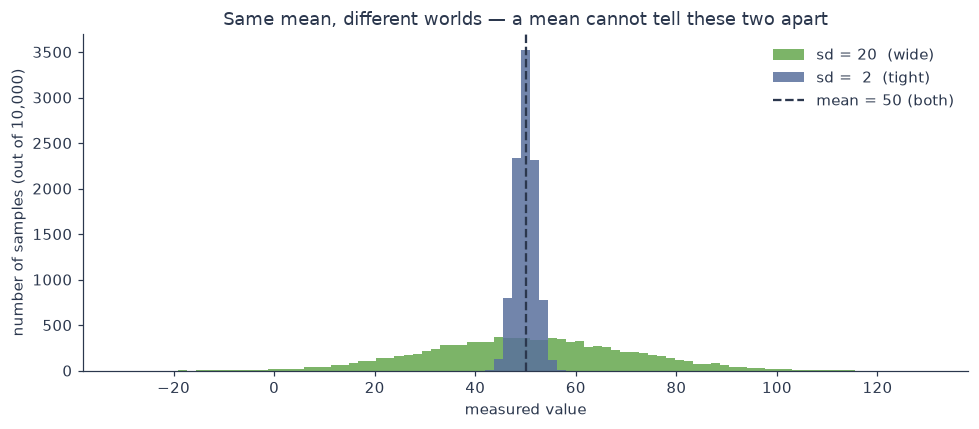

sd =  2: mean =  49.98 | sd =  2.01 | middle 90% of values lie between   46.7 and   53.3
sd = 20: mean =  50.41 | sd = 20.06 | middle 90% of values lie between   17.7 and   84.0

Both means round to 50. If '50' is a delivery estimate, one of these is a promise and the other
is a coin flip — and the mean is the one number that cannot tell you which.


In [2]:
# Pre-work task 2 — two distributions, identical mean, very different variance.
rng = np.random.default_rng(42)          # seeded: your plot == the projector's plot

tight = rng.normal(loc=50, scale=2, size=10_000)   # sd =  2
wide  = rng.normal(loc=50, scale=20, size=10_000)  # sd = 20

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-30, 130, 90)
ax.hist(wide,  bins=bins, color=VSP["green"], alpha=0.85, label="sd = 20  (wide)")
ax.hist(tight, bins=bins, color=VSP["navy"],  alpha=0.85, label="sd =  2  (tight)")
ax.axvline(50, color=VSP["ink"], linestyle="--", linewidth=1.5, label="mean = 50 (both)")
ax.set_xlabel("measured value")
ax.set_ylabel("number of samples (out of 10,000)")
ax.set_title("Same mean, different worlds — a mean cannot tell these two apart")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for name, sample in (("sd =  2", tight), ("sd = 20", wide)):
    lo, hi = np.percentile(sample, [5, 95])
    print(f"{name}: mean = {sample.mean():6.2f} | sd = {sample.std(ddof=1):5.2f} | "
          f"middle 90% of values lie between {lo:6.1f} and {hi:6.1f}")
print()
print("Both means round to 50. If '50' is a delivery estimate, one of these is a promise and the other")
print("is a coin flip — and the mean is the one number that cannot tell you which.")

**Bring to the session:** the plot above (or your own version of it) plus your one written sentence from the
StatQuest videos. Segment 1 opens with three or four of these on screen — same mean, different worlds.

---

# Segment 1 — Distributions as pictures of uncertainty *(12 min)*

A **distribution** answers a question a mean cannot: *which values are plausible, and how plausible?*

We'll look at two datasets senior engineers already have intuition for.

1. **Production API latency** — 100,000 requests through a service. Right-skewed: a fast common case plus a
   long tail of retries, cold starts and cache misses. Target shape from the lesson plan:
   **p50 = 180 ms, mean = 240 ms, p99 = 2.1 s.**
2. **Adult heights** — 5,000 people. Symmetric: one hump, tails of similar length on both sides.

Same summary tool (the mean), two completely different amounts of information carried.

In [3]:
# --- The latency "population": every request the service served this week (100,000 of them).
# Two mechanisms, which is why real latency is skewed:
#   * fast path  (97%) — cache hit, warm connection
#   * slow path  ( 3%) — cold start, retry, cache miss
# Log-normal for both (latency is positive and multiplicative), calibrated to the lesson plan's shape.
N_REQUESTS = 100_000
FAST_MEDIAN, FAST_SIGMA = 177.6, 0.34     # ms
SLOW_MEDIAN, SLOW_SIGMA = 1730.0, 0.45    # ms
SLOW_SHARE = 0.03

rng = np.random.default_rng(42)
is_slow_path = rng.random(N_REQUESTS) < SLOW_SHARE
fast_path = rng.lognormal(np.log(FAST_MEDIAN), FAST_SIGMA, N_REQUESTS)
slow_path = rng.lognormal(np.log(SLOW_MEDIAN), SLOW_SIGMA, N_REQUESTS)
latency_ms = np.where(is_slow_path, slow_path, fast_path)

p50, p95, p99 = np.percentile(latency_ms, [50, 95, 99])
mean_ms = latency_ms.mean()
faster_than_mean = 100 * (latency_ms < mean_ms).mean()

print(f"{N_REQUESTS:,} requests")
print(f"  p50  (median)      : {p50:8.1f} ms   <- the typical request")
print(f"  mean  ('average')  : {mean_ms:8.1f} ms   <- the number on the status page")
print(f"  p95                : {p95:8.1f} ms")
print(f"  p99                : {p99:8.1f} ms   ({p99/1000:.1f} s)")
print(f"  slowest request    : {latency_ms.max():8.1f} ms")
print(f"  standard deviation : {latency_ms.std(ddof=1):8.1f} ms")
print()
print(f"Share of requests FASTER than the 'average' request: {faster_than_mean:.1f}%")
print(f"  -> of every 100 requests, {faster_than_mean:.0f} beat the average. The mean is not the typical case;")
print(f"     it is the median ({p50:.0f} ms) dragged {mean_ms - p50:.0f} ms to the right by the tail.")

# The lesson plan quotes p50 = 180 ms, mean = 240 ms, p99 = 2.1 s — check we reproduced that shape.
assert abs(p50 - 180) < 5 and abs(mean_ms - 240) < 8 and abs(p99 - 2100) < 80, "latency shape drifted"
print("\n[PASS] Shape matches the lesson plan: p50 ~ 180 ms, mean ~ 240 ms, p99 ~ 2.1 s.")

100,000 requests
  p50  (median)      :    180.2 ms   <- the typical request
  mean  ('average')  :    239.8 ms   <- the number on the status page
  p95                :    357.1 ms
  p99                :   2096.8 ms   (2.1 s)
  slowest request    :  11545.8 ms
  standard deviation :    336.4 ms

Share of requests FASTER than the 'average' request: 78.6%
  -> of every 100 requests, 79 beat the average. The mean is not the typical case;
     it is the median (180 ms) dragged 60 ms to the right by the tail.

[PASS] Shape matches the lesson plan: p50 ~ 180 ms, mean ~ 240 ms, p99 ~ 2.1 s.


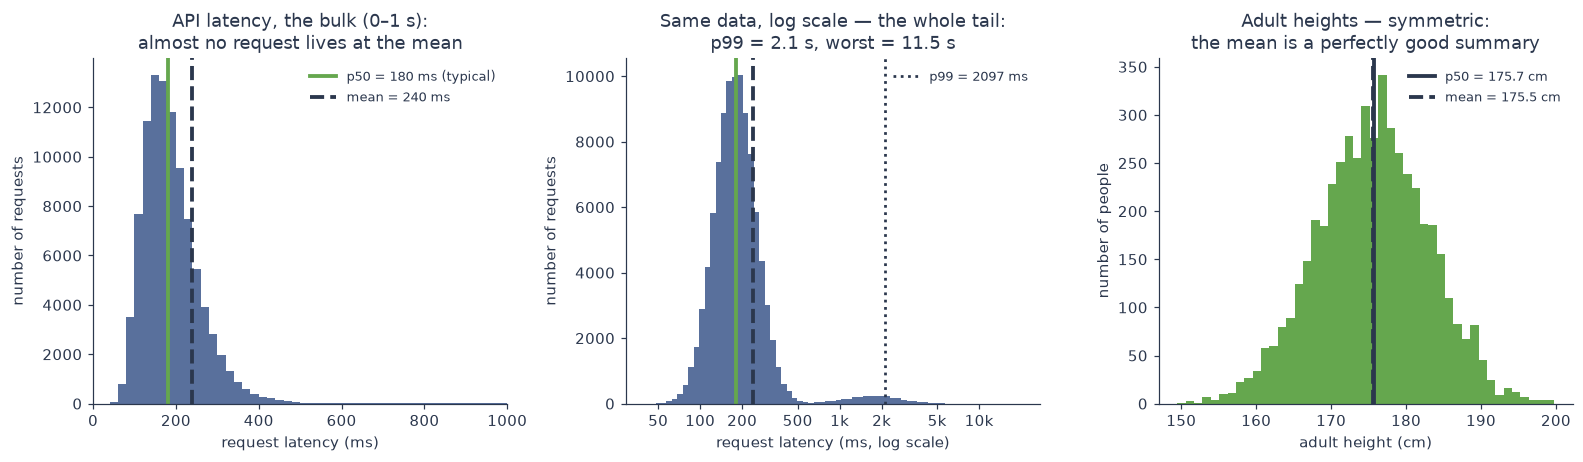

Left panel stops at 1,000 ms — 2.7% of requests are slower than that, which is what the middle panel is for (note the second bump: the 3% slow path).
Heights : mean 175.5 cm vs median 175.7 cm — a 0.1 cm gap. 49% of people are below the mean, i.e. about half.
Latency : mean 240 ms vs median 180 ms — a 60 ms gap. 79% of requests are below the mean.


In [4]:
# --- Adult heights: the well-behaved case, where the mean really is the typical value.
rng = np.random.default_rng(5)
heights_cm = rng.normal(loc=175.3, scale=7.4, size=5_000)   # adult men, cm

fig, (ax_bulk, ax_full, ax_ht) = plt.subplots(1, 3, figsize=(14.5, 4.3))

# 1) The bulk of the latency distribution, linear scale — where the requests actually are.
ax_bulk.hist(latency_ms, bins=np.arange(0, 1020, 20), color=VSP["navy"])
ax_bulk.axvline(p50, color=VSP["green"], linewidth=2.5, label=f"p50 = {p50:.0f} ms (typical)")
ax_bulk.axvline(mean_ms, color=VSP["ink"], linewidth=2.5, linestyle="--", label=f"mean = {mean_ms:.0f} ms")
ax_bulk.set_xlim(0, 1000)
ax_bulk.set_xlabel("request latency (ms)")
ax_bulk.set_ylabel("number of requests")
ax_bulk.set_title("API latency, the bulk (0–1 s):\nalmost no request lives at the mean")
ax_bulk.legend(loc="upper right", fontsize=8.5)
ax_bulk.spines[["top", "right"]].set_visible(False)

# 2) The same data, log x — the only way the 11-second tail and the 180 ms median share a picture.
ax_full.hist(latency_ms, bins=np.logspace(np.log10(40), np.log10(20_000), 70), color=VSP["navy"])
ax_full.set_xscale("log")
ax_full.minorticks_off()
ax_full.set_xticks([50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000])
ax_full.set_xticklabels(["50", "100", "200", "500", "1k", "2k", "5k", "10k"])
ax_full.axvline(p50, color=VSP["green"], linewidth=2.5)
ax_full.axvline(mean_ms, color=VSP["ink"], linewidth=2.5, linestyle="--")
ax_full.axvline(p99, color=VSP["ink"], linewidth=1.8, linestyle=":", label=f"p99 = {p99:.0f} ms")
ax_full.set_xlabel("request latency (ms, log scale)")
ax_full.set_ylabel("number of requests")
ax_full.set_title(f"Same data, log scale — the whole tail:\np99 = {p99/1000:.1f} s, worst = "
                  f"{latency_ms.max()/1000:.1f} s")
ax_full.legend(loc="upper right", fontsize=8.5)
ax_full.spines[["top", "right"]].set_visible(False)

# 3) Symmetric heights, for contrast.
h_mean, h_median = heights_cm.mean(), np.median(heights_cm)
ax_ht.hist(heights_cm, bins=45, color=VSP["green"])
ax_ht.axvline(h_median, color=VSP["ink"], linewidth=2.5, label=f"p50 = {h_median:.1f} cm")
ax_ht.axvline(h_mean, color=VSP["ink"], linewidth=2.5, linestyle="--", label=f"mean = {h_mean:.1f} cm")
ax_ht.set_xlabel("adult height (cm)")
ax_ht.set_ylabel("number of people")
ax_ht.set_title("Adult heights — symmetric:\nthe mean is a perfectly good summary")
ax_ht.legend(loc="upper right", fontsize=8.5)
ax_ht.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Left panel stops at 1,000 ms — {100 * (latency_ms > 1000).mean():.1f}% of requests are slower "
      f"than that, which is what the middle panel is for (note the second bump: the 3% slow path).")
print(f"Heights : mean {h_mean:.1f} cm vs median {h_median:.1f} cm — a {abs(h_mean - h_median):.1f} cm gap. "
      f"{100 * (heights_cm < h_mean).mean():.0f}% of people are below the mean, i.e. about half.")
print(f"Latency : mean {mean_ms:.0f} ms vs median {p50:.0f} ms — a {mean_ms - p50:.0f} ms gap. "
      f"{faster_than_mean:.0f}% of requests are below the mean.")

### What just happened

Both datasets have a mean. Only one of them is *summarised* by it.

- **Heights:** mean ≈ median, tails are short and symmetric. "The average adult man is 175 cm" is a true and
  useful sentence. Roughly half of people are below it — which is what most people *think* an average means.
- **Latency:** mean = 240 ms, median = 180 ms, p99 = 2.1 s. About **4 out of 5 requests are faster than
  "average"**, and the users who are actually suffering live in a tail the mean barely acknowledges. Put
  "average response time: 240 ms" on a status page and you have described almost nobody's experience.

**The rule for the rest of this program:** a distribution answers *which values are plausible, and how
plausible?* A mean answers almost nothing without the shape. When a client hands you one number, your first
move is to ask for the picture.

> **Where you'll see this again:** model outputs are distributions too. "The model is 94% confident" is one
> number pulled from a shape — `LSN-0.4` and `LSN-1.3` take that apart.

---

# Segment 2 — Sampling debrief + bias *(15 min)*

**You ran this simulation in pre-work task 3.** This segment is the debrief, not the demo — the cells
below are here so the numbers are on screen while you talk about them.

You almost never have the population. You have a **sample** — and you report a number computed from it.

We *do* have the population here: those 100,000 requests, whose true mean is a number we can look up. So we
can play the game honestly: take samples of different sizes, compute each sample's mean, and see how far
those estimates land from the truth.

- **1,000 separate samples** of `n = 30` (a quick spot-check: "I curl'd it thirty times")
- **1,000 separate samples** of `n = 3,000` (a proper measurement window)
- **1,000 separate samples** of `n = 30,000` (a serious load test)

Each sample is drawn *with replacement*, so every draw is an independent request from the same traffic
pattern — that's the situation a real measurement is in.

In [5]:
# --- How much does an estimate move around, purely because of who got sampled?
rng = np.random.default_rng(7)
REPEATS = 1_000
SAMPLE_SIZES = (30, 3_000, 30_000)

true_mean = latency_ms.mean()
pop_sd = latency_ms.std(ddof=1)
sample_means = {}

for n in SAMPLE_SIZES:
    sample_means[n] = np.array([rng.choice(latency_ms, size=n, replace=True).mean()
                                for _ in range(REPEATS)])

rows = []
for n in SAMPLE_SIZES:
    means = sample_means[n]
    lo, hi = np.percentile(means, [5, 95])
    rows.append({
        "n per sample": f"{n:,}",
        "lowest estimate": f"{means.min():.0f} ms",
        "highest estimate": f"{means.max():.0f} ms",
        "middle 90% of estimates": f"{lo:.0f} – {hi:.0f} ms",
        "spread (sd of estimates)": f"{means.std(ddof=1):.1f} ms",
        "sd / sqrt(n) predicts": f"{pop_sd / np.sqrt(n):.1f} ms",
    })

print(f"True population mean : {true_mean:.1f} ms   (over all {N_REQUESTS:,} requests)")
print(f"Population sd        : {pop_sd:.1f} ms\n")
display(pd.DataFrame(rows).set_index("n per sample"))

n30 = sample_means[30]
print(f"\nWith n = 30 your answer is anywhere from {n30.min():.0f} ms to {n30.max():.0f} ms — a "
      f"{n30.max() - n30.min():.0f} ms window, and you would report whichever one you happened to get.")
print(f"With n = 30,000 every one of the {REPEATS:,} runs landed between "
      f"{sample_means[30_000].min():.0f} ms and {sample_means[30_000].max():.0f} ms.")

True population mean : 239.8 ms   (over all 100,000 requests)
Population sd        : 336.4 ms



,lowest estimate,highest estimate,middle 90% of estimates,spread (sd of estimates),sd / sqrt(n) predicts
n per sample,,,,,
30,154 ms,544 ms,175 – 374 ms,64.2 ms,61.4 ms
"3,000",218 ms,256 ms,229 – 250 ms,6.2 ms,6.1 ms
"30,000",233 ms,245 ms,237 – 243 ms,2.0 ms,1.9 ms



With n = 30 your answer is anywhere from 154 ms to 544 ms — a 390 ms window, and you would report whichever one you happened to get.
With n = 30,000 every one of the 1,000 runs landed between 233 ms and 245 ms.


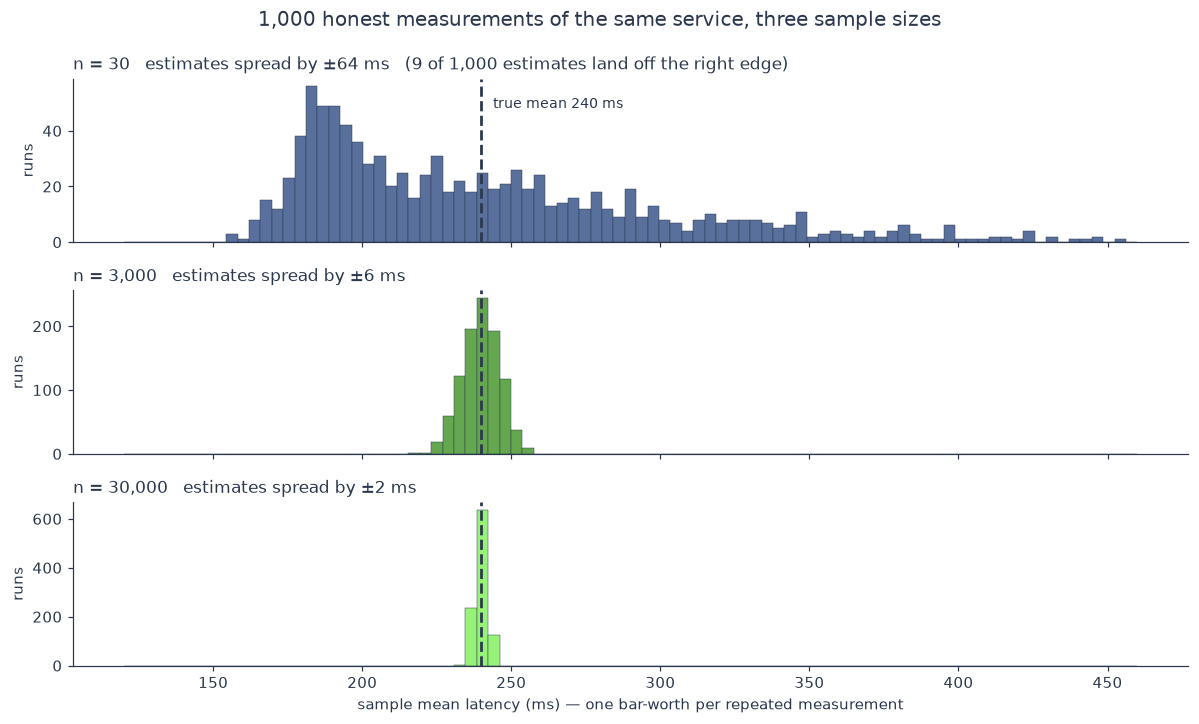

n =     30 : median estimate 226 ms; 57% of runs came in BELOW the true 240 ms.
             Small samples usually miss the slow tail entirely (it is only 3% of traffic), so they
             read low — and the occasional sample that catches a 5-second request reads wildly high.
n = 30,000 : median estimate 240 ms; the tail shows up every time.


In [6]:
# --- Same data, one picture per sample size. Note the shared x-axis.
fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True)
colours = {30: VSP["navy"], 3_000: VSP["green"], 30_000: VSP["mint"]}
edges = np.linspace(120, 460, 90)

for ax, n in zip(axes, SAMPLE_SIZES):
    means = sample_means[n]
    ax.hist(means, bins=edges, color=colours[n], edgecolor=VSP["ink"], linewidth=0.3)
    ax.axvline(true_mean, color=VSP["ink"], linestyle="--", linewidth=1.8)
    off_chart = (means > 460).sum()
    label = (f"n = {n:,}   estimates spread by ±{means.std(ddof=1):.0f} ms"
             + (f"   ({off_chart} of {REPEATS:,} estimates land off the right edge)" if off_chart else ""))
    ax.set_title(label, loc="left", fontsize=11)
    ax.set_ylabel("runs")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].annotate(f"true mean {true_mean:.0f} ms", xy=(true_mean, axes[0].get_ylim()[1] * 0.82),
                 xytext=(8, 0), textcoords="offset points", fontsize=9)
axes[-1].set_xlabel("sample mean latency (ms) — one bar-worth per repeated measurement")
fig.suptitle("1,000 honest measurements of the same service, three sample sizes", y=0.99, fontsize=13)
plt.tight_layout()
plt.show()

print(f"n =     30 : median estimate {np.median(n30):.0f} ms; "
      f"{100 * (n30 < true_mean).mean():.0f}% of runs came in BELOW the true {true_mean:.0f} ms.")
print("             Small samples usually miss the slow tail entirely (it is only 3% of traffic), so they")
print("             read low — and the occasional sample that catches a 5-second request reads wildly high.")
print(f"n = 30,000 : median estimate {np.median(sample_means[30_000]):.0f} ms; the tail shows up every time.")

### The √n rule, in words engineers can use

The spread of your estimate shrinks like **one over the square root of n**:

| going from | data multiplies by | wobble divides by |
|---|---|---|
| 30 → 3,000 | ×100 | ÷10 |
| 3,000 → 30,000 | ×10 | ÷≈3.2 |

Two consequences worth remembering:

- **To halve your uncertainty you need four times the data.** That is why "we'll just collect a bit more"
  is usually not the fix, and why a client's 200-row pilot cannot answer a question their 20,000-row
  production system could.
- **Small samples of skewed data don't just wobble — they lean.** With `n = 30` above, most runs came in
  *below* the truth, because the 3% slow tail simply wasn't in the sample. The error isn't symmetric noise
  you can average away in your head.

**But precision is only half the answer.** Everything above assumed the sample was drawn *fairly*. Next:
what happens when it isn't.

### Bias: the thing no sample size fixes

A latency dashboard that only measures during **EU business hours**, while the user base peaks in the US
evening (EU night, when the system is most loaded). The requests are real. The measurement is careful. The
sample is enormous. And the number is wrong — because *which* requests got measured correlates with *how
slow* they were.

Below: the same 100,000 requests, now tagged with the hour they arrived. Slow requests are more likely to
have happened during the load peak, exactly as in a real system.

In [7]:
# --- Tag every request with an arrival hour, in a way that correlates with latency:
#     the load peak (US evening = 21:00-04:00 CET) collects most of the slow requests.
#     Note this does NOT change the population at all — same 100,000 latencies, only relabelled.
rng = np.random.default_rng(11)

PEAK_HOURS = np.array([21, 22, 23, 0, 1, 2, 3, 4])                      # load peak (CET)
OFF_HOURS = np.array([h for h in range(24) if h not in set(PEAK_HOURS.tolist())])

median_ms, p95_ms = np.percentile(latency_ms, [50, 95])
p_peak = np.where(latency_ms > p95_ms, 0.90,                # worst requests: nearly always at peak
                  np.where(latency_ms > median_ms, 0.62,    # slower half:    mostly at peak
                           0.20))                          # faster half:    rarely at peak
in_peak = rng.random(N_REQUESTS) < p_peak
hour = np.where(in_peak, rng.choice(PEAK_HOURS, N_REQUESTS), rng.choice(OFF_HOURS, N_REQUESTS))

business_hours = (hour >= 9) & (hour <= 17)          # what the EU-hours dashboard can see
dashboard_pool = latency_ms[business_hours]

# The dashboard takes a HUGE sample — 30,000 requests — but only from business hours.
sample = rng.choice(dashboard_pool, size=30_000, replace=True)
se = sample.std(ddof=1) / np.sqrt(sample.size)

truth = {"mean": latency_ms.mean(), "p95": np.percentile(latency_ms, 95), "p99": np.percentile(latency_ms, 99)}
dash = {"mean": dashboard_pool.mean(), "p95": np.percentile(dashboard_pool, 95),
        "p99": np.percentile(dashboard_pool, 99)}

print(f"Business hours hold {100 * business_hours.mean():.0f}% of the traffic "
      f"({business_hours.sum():,} requests) — plenty to sample from.\n")
comparison = pd.DataFrame(
    {"EU-business-hours dashboard": [f"{dash['mean']:.0f} ms", f"{dash['p95']:.0f} ms", f"{dash['p99']:.0f} ms"],
     "what users actually got": [f"{truth['mean']:.0f} ms", f"{truth['p95']:.0f} ms", f"{truth['p99']:.0f} ms"],
     "understated by": [f"{100 * (1 - dash['mean'] / truth['mean']):.0f}%",
                        f"{100 * (1 - dash['p95'] / truth['p95']):.0f}%",
                        f"{100 * (1 - dash['p99'] / truth['p99']):.0f}%"]},
    index=["mean latency", "p95", "p99"])
display(comparison)

print(f"\nThe dashboard's 30,000-request sample reports {sample.mean():.1f} ms "
      f"+/- {1.96 * se:.1f} ms (95% interval).")
print(f"The true mean is {truth['mean']:.0f} ms — about "
      f"{(truth['mean'] - sample.mean()) / se:.0f} standard errors away from that estimate, so no honest "
      f"confidence interval\nwill ever reach it.")
print("[FAIL] Precise, repeatable, defensible-looking — and wrong. More data made the wrong answer")
print("       *tighter*, not truer. Bias is not noise; averaging does not remove it.")

Business hours hold 33% of the traffic (32,541 requests) — plenty to sample from.



,EU-business-hours dashboard,what users actually got,understated by
mean latency,177 ms,240 ms,26%
p95,285 ms,357 ms,20%
p99,353 ms,2097 ms,83%



The dashboard's 30,000-request sample reports 176.4 ms +/- 1.6 ms (95% interval).
The true mean is 240 ms — about 78 standard errors away from that estimate, so no honest confidence interval
will ever reach it.
[FAIL] Precise, repeatable, defensible-looking — and wrong. More data made the wrong answer
       *tighter*, not truer. Bias is not noise; averaging does not remove it.


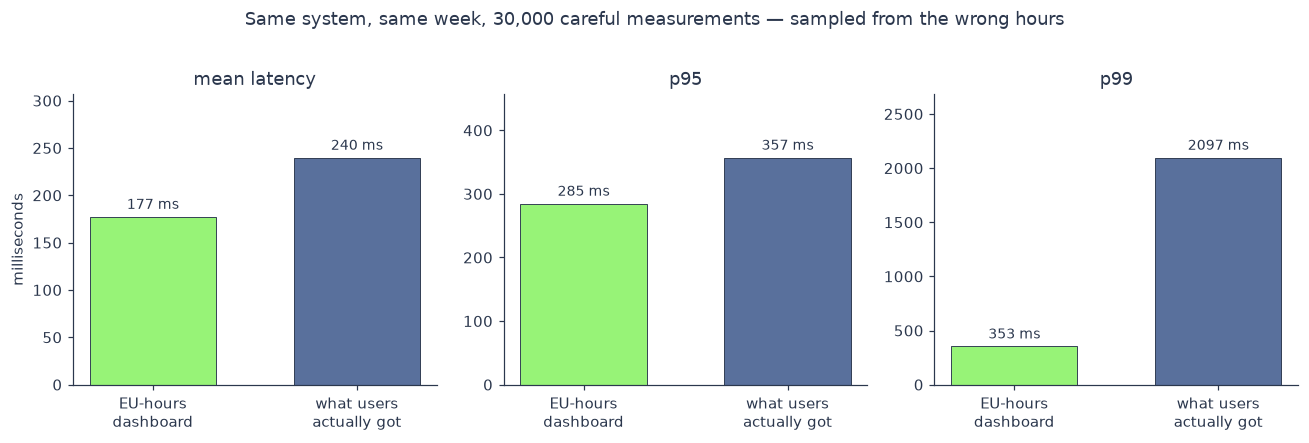

In [8]:
# --- One picture: what the dashboard reports vs what users experienced.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
metrics = [("mean latency", "mean"), ("p95", "p95"), ("p99", "p99")]

for ax, (title, key) in zip(axes, metrics):
    values = [dash[key], truth[key]]
    bars = ax.bar(["EU-hours\ndashboard", "what users\nactually got"], values,
                  color=[VSP["mint"], VSP["navy"]], edgecolor=VSP["ink"], linewidth=0.6, width=0.62)
    ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("milliseconds" if key == "mean" else "")
    ax.set_ylim(0, max(values) * 1.28)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Same system, same week, 30,000 careful measurements — sampled from the wrong hours",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### Two questions for any number, ever

> **1. How many?**  **2. Collected how?**

Three bias classics worth having in your pocket for a client conversation:

| The sample | Why it lies |
|---|---|
| **An NPS survey only angry users answer** | Response is *caused by* the thing being measured. Ten thousand responses won't fix it — you've measured "how angry are angry people". |
| **Latency measured only in EU business hours** | The cell above. The sample excludes the load peak, so the tail is invisible and the number looks great. |
| **Wald's WWII bombers** | Analysts wanted armour where returning planes had bullet holes. Abraham Wald pointed out the planes hit *elsewhere* never came back — so armour the places with **no** holes. The sample was "survivors", and the whole conclusion inverted. |

**Generic "watch out for bias" is unactionable. A named list is checkable.** Six types, each with the
tell you would actually notice in a client's data:

| Type | The tell in commercial data |
|---|---|
| **Reporting** | What gets recorded isn't how often things happen. Support tickets capture complaints, never satisfaction — train on tickets and you learn a world where everything is broken. |
| **Selection** | The CRM holds the deals somebody bothered to log. Deals that died in week one are missing, so the model never learns what a dying deal looks like. |
| **Temporal** | The population changed between collection and now. Two years of pre-reorganisation delivery data, used to estimate post-reorganisation delivery. |
| **In-group** | Whoever labelled it favoured what they recognised. Estimators rate work resembling their own past projects as lower risk. |
| **Out-group homogeneity** | Everything unfamiliar gets treated as interchangeable — every client in a new sector scored against one generic profile. |
| **Confirmation** | The analysis that keeps getting rerun until it agrees with the pitch. |

**Drill (live, 4 min).** One dataset description: *"18 months of won and lost deals, exported from the
CRM."* Which of the six are in there? There are at least three, and the room finds them without help.

Survivorship is the sneaky one, and it's everywhere in client data: the projects that finished, the
customers who stayed, the deals that closed. **Ask what's missing from the table before you trust the
average of what's in it** — you'll do exactly that in tonight's homework.

---

# Segment 3 — Variance and outliers: when the average lies *(13 min)*

## Two delivery teams, one number, two very different promises

Both teams average **5 days** cycle time. Team A's standard deviation is **0.5 days**; Team B's is
**4 days**. The client wants a commitment.

(Cycle times are drawn from gamma distributions rather than normals for one honest reason: a cycle time
can't be negative, and a normal with mean 5 and sd 4 would happily hand you −2 days.)

In [9]:
# --- Two teams, same mean cycle time, different variance.
TEAM_MEAN = 5.0
SD_A, SD_B = 0.5, 4.0
N_TICKETS = 600

# gamma parameterised from a target mean/sd: shape = (mean/sd)^2, scale = sd^2/mean
rng = np.random.default_rng(51)
team_a = rng.gamma((TEAM_MEAN / SD_A) ** 2, SD_A ** 2 / TEAM_MEAN, N_TICKETS)
team_b = rng.gamma((TEAM_MEAN / SD_B) ** 2, SD_B ** 2 / TEAM_MEAN, N_TICKETS)

COMMITMENT = 6.0   # days we are thinking of promising the client

summary = pd.DataFrame({
    "Team A (sd 0.5)": [team_a.mean(), np.median(team_a), team_a.std(ddof=1),
                        np.percentile(team_a, 90), team_a.max(), 100 * (team_a <= COMMITMENT).mean()],
    "Team B (sd 4.0)": [team_b.mean(), np.median(team_b), team_b.std(ddof=1),
                        np.percentile(team_b, 90), team_b.max(), 100 * (team_b <= COMMITMENT).mean()],
}, index=["mean (days)", "median (days)", "sd (days)", "p90 (days)", "worst ticket (days)",
          f"% delivered within {COMMITMENT:.0f} days"]).round(2)
display(summary)

miss_a = int(round((team_a > COMMITMENT).mean() * 100))
miss_b = int(round((team_b > COMMITMENT).mean() * 100))
print(f"Promise the client {COMMITMENT:.0f} days, per ticket:")
print(f"  Team A breaks that promise about {miss_a} times in 100.")
print(f"  Team B breaks that promise about {miss_b} times in 100 — same average, ten times the apologies.")
print(f"\nTo be right 9 times out of 10 you would quote {np.percentile(team_a, 90):.1f} days for Team A "
      f"and {np.percentile(team_b, 90):.1f} days for Team B.")
print(f"Note Team B's median ({np.median(team_b):.1f} d) sits well below its mean ({team_b.mean():.1f} d): "
      f"skewed again, so\n'average' overstates the typical ticket and understates the bad one.")

,Team A (sd 0.5),Team B (sd 4.0)
mean (days),4.99,4.99
median (days),4.98,3.85
sd (days),0.51,3.99
p90 (days),5.68,9.79
worst ticket (days),6.74,33.43
% delivered within 6 days,96.83,68.33


Promise the client 6 days, per ticket:
  Team A breaks that promise about 3 times in 100.
  Team B breaks that promise about 32 times in 100 — same average, ten times the apologies.

To be right 9 times out of 10 you would quote 5.7 days for Team A and 9.8 days for Team B.
Note Team B's median (3.9 d) sits well below its mean (5.0 d): skewed again, so
'average' overstates the typical ticket and understates the bad one.


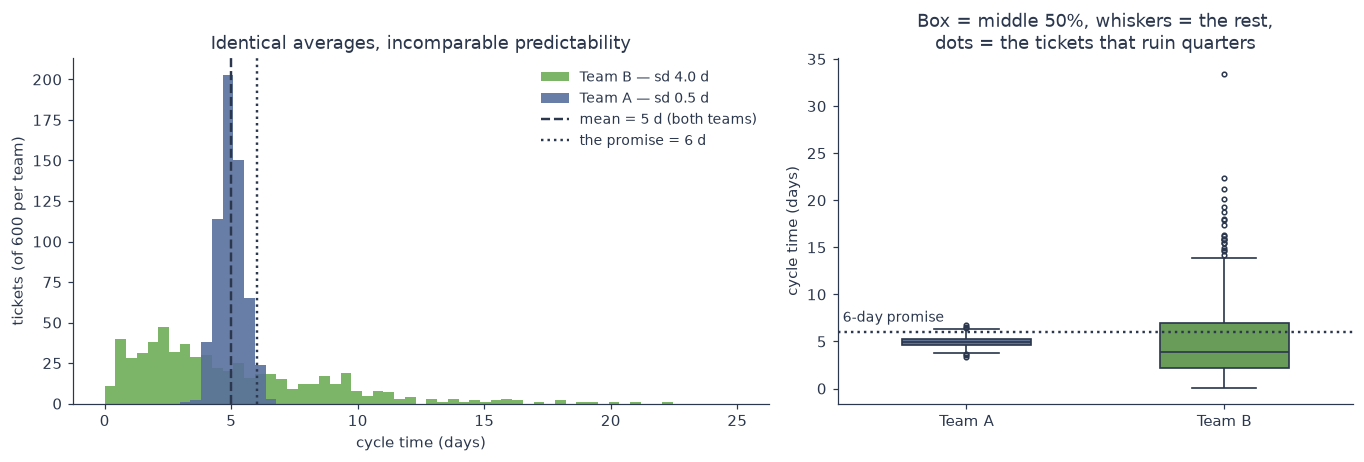

In [10]:
# --- Left: the two shapes. Right: the same data as boxplots — median, quartiles, outliers.
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(12.5, 4.3), gridspec_kw={"width_ratios": [1.35, 1]})

edges = np.linspace(0, 25, 60)
ax_hist.hist(team_b, bins=edges, color=VSP["green"], alpha=0.85, label=f"Team B — sd {SD_B:.1f} d")
ax_hist.hist(team_a, bins=edges, color=VSP["navy"], alpha=0.9, label=f"Team A — sd {SD_A:.1f} d")
ax_hist.axvline(TEAM_MEAN, color=VSP["ink"], linestyle="--", linewidth=1.6,
                label=f"mean = {TEAM_MEAN:.0f} d (both teams)")
ax_hist.axvline(COMMITMENT, color=VSP["ink"], linestyle=":", linewidth=1.6,
                label=f"the promise = {COMMITMENT:.0f} d")
ax_hist.set_xlabel("cycle time (days)")
ax_hist.set_ylabel(f"tickets (of {N_TICKETS} per team)")
ax_hist.set_title("Identical averages, incomparable predictability")
ax_hist.legend(fontsize=9)
ax_hist.spines[["top", "right"]].set_visible(False)

tickets = pd.DataFrame({
    "team": ["Team A"] * N_TICKETS + ["Team B"] * N_TICKETS,
    "cycle_time_days": np.concatenate([team_a, team_b]),
})
sns.boxplot(data=tickets, x="team", y="cycle_time_days", hue="team", legend=False,
            palette={"Team A": VSP["navy"], "Team B": VSP["green"]}, width=0.5,
            fliersize=3, linecolor=VSP["ink"], linewidth=1.1, ax=ax_box)
ax_box.axhline(COMMITMENT, color=VSP["ink"], linestyle=":", linewidth=1.6)
ax_box.text(-0.48, COMMITMENT + 1.1, f"{COMMITMENT:.0f}-day promise", fontsize=9, ha="left")
ax_box.set_xlabel("")
ax_box.set_ylabel("cycle time (days)")
ax_box.set_title("Box = middle 50%, whiskers = the rest,\ndots = the tickets that ruin quarters")
ax_box.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Discussion (2 min, out loud):** whose number do you put in a client commitment — and what do you *say*
about Team B? The useful answer is never "5 days". It's "half of B's work lands in 2 to 7 days, one ticket
in ten takes more than 10, and here's the p90 I'd sign up to."

**Variance is a promise-keeping metric.** Two teams with the same mean are not equally safe to sell.

## One deal moves the "average deal size" by 2.6×

Fifteen closed deals from a sales quarter: fourteen normal ones and one enterprise whale at **$2.0M**.

,14 deals (no whale),15 deals (with the $2M whale)
deals,14,15
mean deal size,"$80,000","$208,000"
median deal size,"$73,500","$75,000"


mean   : $80,000  ->  $208,000   (2.60x, from one deal in fifteen)
median : $73,500  ->  $75,000   (moved $1,500 — the outlier barely touches it)

Deals at or above the new 'average deal size' of $208,000: 1 of 15.
Set next quarter's quota on that average and you have set it above 14 of your last 15 deals.


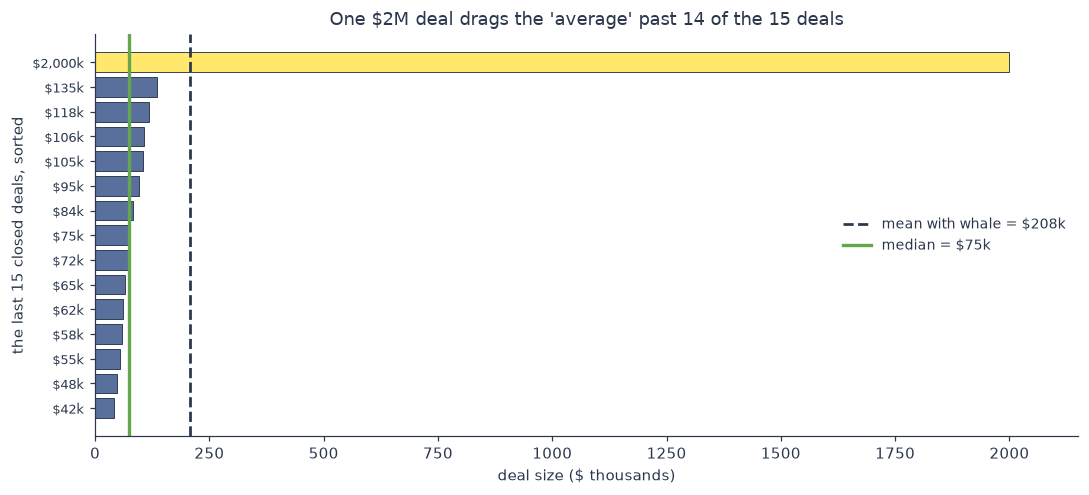

In [11]:
# --- 15 closed deals; the 14 normal ones average exactly $80k, then one $2M whale lands.
normal_deals = np.array([42, 48, 55, 58, 62, 65, 72, 75, 84, 95, 105, 106, 118, 135]) * 1_000
whale = 2_000_000
all_deals = np.append(normal_deals, whale)

stats = pd.DataFrame({
    "14 deals (no whale)": [f"{len(normal_deals)}", f"${normal_deals.mean():,.0f}",
                            f"${np.median(normal_deals):,.0f}"],
    "15 deals (with the $2M whale)": [f"{len(all_deals)}", f"${all_deals.mean():,.0f}",
                                      f"${np.median(all_deals):,.0f}"],
}, index=["deals", "mean deal size", "median deal size"])
display(stats)

print(f"mean   : ${normal_deals.mean():,.0f}  ->  ${all_deals.mean():,.0f}   "
      f"({all_deals.mean() / normal_deals.mean():.2f}x, from one deal in fifteen)")
print(f"median : ${np.median(normal_deals):,.0f}  ->  ${np.median(all_deals):,.0f}   "
      f"(moved ${np.median(all_deals) - np.median(normal_deals):,.0f} — the outlier barely touches it)")
print(f"\nDeals at or above the new 'average deal size' of ${all_deals.mean():,.0f}: "
      f"{(all_deals >= all_deals.mean()).sum()} of {len(all_deals)}.")
print("Set next quarter's quota on that average and you have set it above 14 of your last 15 deals.")

fig, ax = plt.subplots(figsize=(10, 4.6))
sorted_deals = np.sort(all_deals)
colours = [VSP["yellow"] if v == whale else VSP["navy"] for v in sorted_deals]
ax.barh(range(len(sorted_deals)), sorted_deals / 1_000, color=colours,
        edgecolor=VSP["ink"], linewidth=0.6)
ax.set_yticks(range(len(sorted_deals)))
ax.set_yticklabels([f"${v / 1_000:,.0f}k" for v in sorted_deals], fontsize=8.5)
ax.axvline(all_deals.mean() / 1_000, color=VSP["ink"], linestyle="--", linewidth=1.8,
           label=f"mean with whale = ${all_deals.mean() / 1_000:,.0f}k")
ax.axvline(np.median(all_deals) / 1_000, color=VSP["green"], linewidth=2.2,
           label=f"median = ${np.median(all_deals) / 1_000:,.0f}k")
ax.set_xlabel("deal size ($ thousands)")
ax.set_ylabel("the last 15 closed deals, sorted")
ax.set_title("One $2M deal drags the 'average' past 14 of the 15 deals")
ax.set_xlim(0, 2_150)
ax.legend(loc="center right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### The fixes — four of them, all cheap

1. **Report the median** when the distribution is skewed or has outliers. It answers "what's typical?"
   without a single deal or a single 11-second request voting fifteen times.
2. **Report percentiles, not just the centre.** p50/p90/p99 *is* the shape, compressed to three numbers.
   Every SRE already lives this way; apply it to cycle times, deal sizes and model errors too.
3. **Use a rule to exclude, not an eyeball.** "That point looks wrong" is an opinion; the **1.5 × IQR
   fence** is a method. Q1 and Q3 are the 25th and 75th percentiles, `IQR = Q3 - Q1`, and anything
   outside `Q1 - 1.5 × IQR` or `Q3 + 1.5 × IQR` is flagged. That is exactly what the box plot above
   draws — the whiskers stop at the fences, and everything past them gets its own dot.
4. **Plot it before you summarise it.** Which is what the homework's Anscombe task is for.

> **The fence flags the point. It does not tell you what to do with it.** Sometimes the outlier is bad
> data; sometimes it is the entire business case — the fraud, the defect, the whale. The rule buys you
> a defensible answer to the only question that matters in a review: **"which points did you exclude,
> and by what rule?"** A vendor who cannot answer that has hand-tuned their metric.

In [12]:
# --- The fence, on the deal data you just saw. Five lines, no library beyond numpy.
q1, q3 = np.percentile(all_deals, [25, 75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
kept = all_deals[(all_deals >= lower_fence) & (all_deals <= upper_fence)]
flagged = all_deals[(all_deals < lower_fence) | (all_deals > upper_fence)]

print(f"Q1 = ${q1:,.0f}     Q3 = ${q3:,.0f}     IQR = ${iqr:,.0f}")
print(f"Fences: below ${lower_fence:,.0f}  or above ${upper_fence:,.0f}")
print(f"Flagged by the rule: {len(flagged)} of {len(all_deals)} deals -> "
      f"{', '.join(f'${v:,.0f}' for v in np.sort(flagged))}\n")
print(f"Mean, everything          : ${all_deals.mean():,.0f}")
print(f"Mean, flagged excluded    : ${kept.mean():,.0f}")
print(f"Median (barely moves)     : ${np.median(all_deals):,.0f}")

assert whale in flagged, "the $2M deal should be outside the upper fence"
print("\n[PASS] The rule found the whale without anyone eyeballing the chart.")
print("Note what it did NOT do: it did not tell you to delete that deal - it is the best thing that")
print("happened all year. It told you the AVERAGE is not describing it, which is a far more useful")
print("sentence, and it gave you a defensible answer to 'by what rule did you exclude it?'")

Q1 = $60,000     Q3 = $105,500     IQR = $45,500
Fences: below $-8,250  or above $173,750
Flagged by the rule: 1 of 15 deals -> $2,000,000

Mean, everything          : $208,000
Mean, flagged excluded    : $80,000
Median (barely moves)     : $75,000

[PASS] The rule found the whale without anyone eyeballing the chart.
Note what it did NOT do: it did not tell you to delete that deal - it is the best thing that
happened all year. It told you the AVERAGE is not describing it, which is a far more useful
sentence, and it gave you a defensible answer to 'by what rule did you exclude it?'


---

# Segment 4 — Client drill: *"our model is 92% accurate"* **(20 min)**

## The scenario card

> A construction-firm prospect is evaluating vendors for **milestone tracking**. Their incumbent's pitch:
> *"Our model detects completed milestones from site photos with **92% accuracy**."*
>
> The prospect's PM turns to you: **"Sounds great — should we just go with them?"**

*Pairs: 5 minutes to prepare. Two or three pairs then run the conversation live against Tyler playing the
prospect. 8 minutes of debrief.*

Now the numbers behind the claim. The vendor's test set is **1,000 site photos: 920 labelled "in progress"
and 80 labelled "milestone complete."** Before you read on, compute the accuracy of the laziest possible
model — one that ignores the photo entirely and answers **"in progress"** every single time.

In [13]:
# --- The vendor's test set: 1,000 photos, 920 "in progress", 80 "milestone complete".
N_PHOTOS, N_COMPLETE = 1_000, 80
N_IN_PROGRESS = N_PHOTOS - N_COMPLETE

truth_labels = np.array(["in progress"] * N_IN_PROGRESS + ["milestone complete"] * N_COMPLETE, dtype=object)

# The laziest model in the world: never looks at the photo, always says "in progress".
lazy_prediction = np.full(N_PHOTOS, "in progress", dtype=object)

accuracy = (lazy_prediction == truth_labels).mean()
found = int(((lazy_prediction == "milestone complete") & (truth_labels == "milestone complete")).sum())

print(f"Test set : {N_PHOTOS:,} photos = {N_IN_PROGRESS} 'in progress' + {N_COMPLETE} 'milestone complete'")
print(f"Model    : answers 'in progress' every time. It has no idea what a photo is.\n")
print(f"  correct answers      : {int((lazy_prediction == truth_labels).sum()):>5} / {N_PHOTOS:,}")
print(f"  ACCURACY             : {accuracy:>6.1%}   <- the vendor's headline number, exactly")
print(f"  completed milestones found : {found} of {N_COMPLETE}\n")

per_class = pd.crosstab(pd.Series(truth_labels, name="actual"),
                        pd.Series(lazy_prediction, name="model said"))
display(per_class)

print(f"[PASS] {accuracy:.0%} accuracy, achieved by a model that detects nothing at all.")
print(f"       Accuracy on 'in progress' photos : 100%")
print(f"       Accuracy on 'milestone complete' : 0%  ({N_COMPLETE} of {N_COMPLETE} missed)")
print("       Every milestone invoice on that site would be late, and the scorecard would look great.")

Test set : 1,000 photos = 920 'in progress' + 80 'milestone complete'
Model    : answers 'in progress' every time. It has no idea what a photo is.

  correct answers      :   920 / 1,000
  ACCURACY             :  92.0%   <- the vendor's headline number, exactly
  completed milestones found : 0 of 80



model said,in progress
actual,
in progress,920
milestone complete,80


[PASS] 92% accuracy, achieved by a model that detects nothing at all.
       Accuracy on 'in progress' photos : 100%
       Accuracy on 'milestone complete' : 0%  (80 of 80 missed)
       Every milestone invoice on that site would be late, and the scorecard would look great.


### Where the 92% came from

> **920** photos that really were "in progress" **÷ 1,000** photos in the test set **= 92%**

The number wasn't a lie. It was **the class balance of the test set wearing a lab coat**. On this test set,
92% is the *floor* — the score you get for free by never detecting anything — not a level of skill.

And that's the fun part of the drill: you cannot know that from the pitch. You have to ask.

,headline accuracy,completions found,missed completions (late invoicing),false completions (billing unfinished work)
vendor,,,,
A — 'we are 92% accurate',92.0%,0 of 80,80,0
B — quieter headline,89.2%,72 of 80,8,100


Vendor A wins on the headline: 92.0% vs 89.2%.
Vendor B finds 72 of 80 real completions (90%); vendor A finds none.
Of vendor B's 172 'complete!' alerts, 72 are real — 42%. Someone has to check the other 100.

So: accuracy ranked these two backwards for the job the client actually cares about.
Those two error columns have formal names — precision and recall — and LSN-1.3 makes them yours.


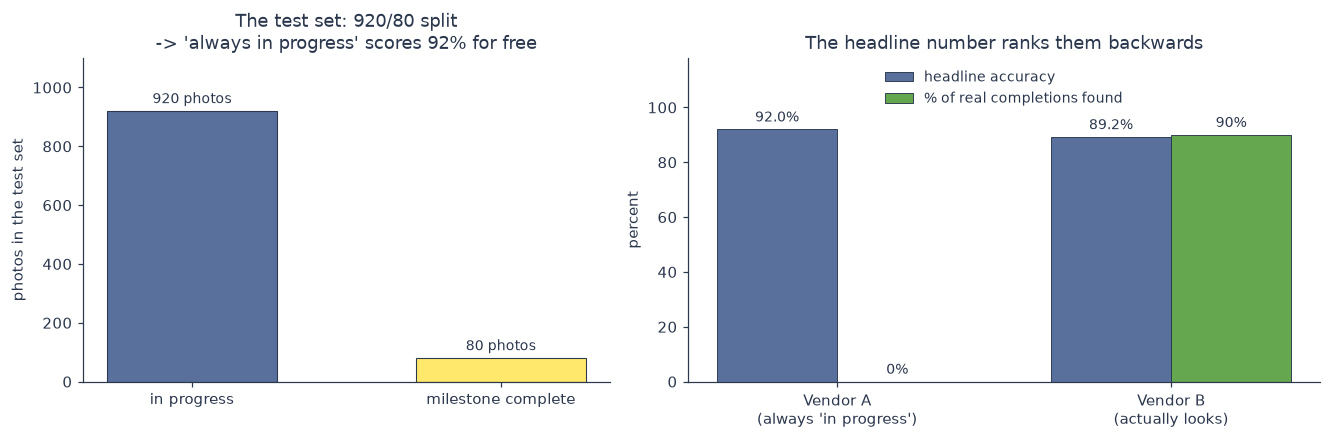

In [14]:
# --- A second vendor, to show that accuracy can rank two models backwards.
# Vendor B catches 72 of the 80 real completions, at the cost of 100 false alarms.
rng = np.random.default_rng(1337)
idx_complete = np.flatnonzero(truth_labels == "milestone complete")
idx_progress = np.flatnonzero(truth_labels == "in progress")

vendor_b = np.full(N_PHOTOS, "in progress", dtype=object)
vendor_b[rng.choice(idx_complete, size=72, replace=False)] = "milestone complete"   # caught
vendor_b[rng.choice(idx_progress, size=100, replace=False)] = "milestone complete"  # false alarms


def score(prediction, name):
    is_flag = prediction == "milestone complete"
    is_real = truth_labels == "milestone complete"
    return {
        "vendor": name,
        "headline accuracy": f"{(prediction == truth_labels).mean():.1%}",
        "completions found": f"{int((is_flag & is_real).sum())} of {N_COMPLETE}",
        "missed completions (late invoicing)": int((~is_flag & is_real).sum()),
        "false completions (billing unfinished work)": int((is_flag & ~is_real).sum()),
    }


scores = pd.DataFrame([score(lazy_prediction, "A — 'we are 92% accurate'"),
                       score(vendor_b, "B — quieter headline")]).set_index("vendor")
display(scores)

acc_a = (lazy_prediction == truth_labels).mean()
acc_b = (vendor_b == truth_labels).mean()
flagged_b = int((vendor_b == "milestone complete").sum())
print(f"Vendor A wins on the headline: {acc_a:.1%} vs {acc_b:.1%}.")
print(f"Vendor B finds 72 of {N_COMPLETE} real completions ({72 / N_COMPLETE:.0%}); vendor A finds none.")
print(f"Of vendor B's {flagged_b} 'complete!' alerts, 72 are real — "
      f"{72 / flagged_b:.0%}. Someone has to check the other {flagged_b - 72}.")
print("\nSo: accuracy ranked these two backwards for the job the client actually cares about.")
print("Those two error columns have formal names — precision and recall — and LSN-1.3 makes them yours.")

fig, (ax_bal, ax_cmp) = plt.subplots(1, 2, figsize=(12.2, 4.1), gridspec_kw={"width_ratios": [1, 1.2]})

bars = ax_bal.bar(["in progress", "milestone complete"], [N_IN_PROGRESS, N_COMPLETE],
                  color=[VSP["navy"], VSP["yellow"]], edgecolor=VSP["ink"], linewidth=0.7, width=0.55)
ax_bal.bar_label(bars, fmt="%d photos", padding=3, fontsize=9)
ax_bal.set_ylim(0, 1_100)
ax_bal.set_ylabel("photos in the test set")
ax_bal.set_title(f"The test set: {N_IN_PROGRESS}/{N_COMPLETE} split\n"
                 f"-> 'always in progress' scores {acc_a:.0%} for free")
ax_bal.spines[["top", "right"]].set_visible(False)

x = np.arange(2)
w = 0.36
acc_vals = [100 * acc_a, 100 * acc_b]
found_vals = [0, 100 * 72 / N_COMPLETE]
b1 = ax_cmp.bar(x - w / 2, acc_vals, w, color=VSP["navy"], edgecolor=VSP["ink"],
                linewidth=0.6, label="headline accuracy")
b2 = ax_cmp.bar(x + w / 2, found_vals, w, color=VSP["green"], edgecolor=VSP["ink"],
                linewidth=0.6, label="% of real completions found")
ax_cmp.bar_label(b1, fmt="%.1f%%", padding=3, fontsize=9)
ax_cmp.bar_label(b2, fmt="%.0f%%", padding=3, fontsize=9)
ax_cmp.set_xticks(x)
ax_cmp.set_xticklabels(["Vendor A\n(always 'in progress')", "Vendor B\n(actually looks)"])
ax_cmp.set_ylim(0, 118)
ax_cmp.set_ylabel("percent")
ax_cmp.set_title("The headline number ranks them backwards")
ax_cmp.legend(fontsize=9, loc="upper center")
ax_cmp.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## The three questions to ask before believing any accuracy claim

**1. 92% *on what data?***
Held-out data, or the data it trained on? From the same sites, cameras, seasons and lighting it will see in
production — or from a curated demo set? (This is segment 2 again: *how many, and collected how.* A model
evaluated on summer photos from three tidy sites has told you about summer photos from three tidy sites.)

**2. What's the *class balance?***
If 92% of the photos are "in progress", then 92% accuracy is free — you just computed it. **What is the
accuracy on *each class* separately?** For vendor A: 100% on "in progress", 0% on "complete".

**3. Which mistakes make up the missing 8%?**
Eight percent of 1,000 photos is 80 errors, and *which* 80 decides whether this is a rounding error or a
lawsuit:
- **missed completions** → milestones detected late → **invoices go out late**, cash-flow pain;
- **false completions** → **billing for unfinished work** → the client's client finds out.
These cost differently, so they are not interchangeable — and a single accuracy number cannot tell them
apart. *This question has formal names:* **precision and recall**, with the confusion matrix behind them.
That's `LSN-1.3` — **Grading models** — and you'll do the arithmetic there. Today it's enough that you never
again accept one accuracy number without asking which errors it hides.

> **The answer to the PM's question** — "should we just go with them?" — is never "no". It's: *"Maybe. Ask
> them for accuracy per class on a held-out set from your sites, and the split between missed and false
> completions. If they can't produce it, that 92% is the class balance of their test set."*

In [15]:
# --- Drill prep (5 min, in pairs). Type your three questions in your own words.
# This cell never fails — it just tells you what is still blank.
MY_THREE_QUESTIONS = [
    "",   # 1 — about the DATA the 92% was measured on
    "",   # 2 — about the CLASS BALANCE of that test set
    "",   # 3 — about WHICH MISTAKES make up the missing 8%
]

blank = [i + 1 for i, q in enumerate(MY_THREE_QUESTIONS) if len(q.strip()) < 15]
if blank:
    print(f"[TODO] Question(s) {', '.join(map(str, blank))} still blank — "
          "write them the way you'd actually say them out loud to a prospect.")
    print("       Rule of thumb: if a vendor could answer it with 'yes', it isn't a good question yet.")
else:
    print("[PASS] Three questions ready. Deliver them as curiosity, not cross-examination —")
    print("       you are helping the PM buy well, not catching the incumbent out.")
    for i, q in enumerate(MY_THREE_QUESTIONS, start=1):
        print(f"  {i}. {q.strip()}")

[TODO] Question(s) 1, 2, 3 still blank — write them the way you'd actually say them out loud to a prospect.
       Rule of thumb: if a vendor could answer it with 'yes', it isn't a good question yet.


---

# Homework — 90 min

| # | Task | Time |
|---|---|---|
| 1 | The 32 fixed-bid projects — mean/median/variance, histogram, the fence, the trust write-up | 30 min |
| 2 | The whale table, and Anscombe as a prediction you commit to before you plot | 25 min |
| 3 | The three questions, written as an email to the prospect's PM | 15 min |
| 4 | The two sampling questions, applied to a number from your own project | 10 min |
| 5 | Notebook extension — sampling on the right-skewed population | 10 min |

---

## Task 1 — 32 fixed-bid projects, one ugly row

*Graded pass/fail on the **interpretation**, not the code. Feeds `ASM-0`. Reference `LSN-0.2` on submission.*

The dataset below is real in shape: **schedule slip in days** for the last 32 fixed-bid projects
(negative = delivered early, positive = late). It contains one **+45-day** row.

**Your tasks**

1. Compute the **mean, median and variance** of `slip_days`.
2. **Plot the histogram.**
3. **Identify the outlier using the 1.5 × IQR fence** — not by eye — and recompute the mean without it.
   Report the fence values you computed, because "which points did you exclude, and by what rule?" is
   the question you will be asked.
4. Write **two sentences**: (a) would you trust a model trained on these 32 points to predict overrun for a
   new project, and (b) what one thing about **how this sample was collected** would you check first?

**How this sample was collected** — read this before you answer (4b):

> These are the fixed-bid projects that **reached completion** and had clean records in the PMO tracker.
> Projects cancelled mid-flight, renegotiated into time-and-materials, or delivered before the tracker
> existed are not in the table.

Do the work in the workspace cell, then put your answers in the fill-in cell. The fill-in cell checks your
arithmetic, never crashes, and saves your submission to `outputs/lsn-0.2/` once it's complete.

In [16]:
# --- The provided dataset: 32 completed fixed-bid projects (seeded, so everyone grades the same table).
rng = np.random.default_rng(2026)
slips = np.append(np.rint(rng.normal(4.0, 6.5, 31)).astype(int), 45)   # 31 ordinary projects + one +45
slips = slips[np.random.default_rng(2027).permutation(len(slips))]     # shuffle so the outlier isn't last

sectors = ["public sector", "retail", "logistics", "fintech"]
# 14 quarters of history, Q1 2023 through Q2 2026, 2-3 projects closing per quarter (chronological).
quarters = [f"Q{q} {y}" for y in (2023, 2024, 2025, 2026) for q in (1, 2, 3, 4)][:14]
projects = pd.DataFrame({
    "project_id": [f"PRJ-{100 + i}" for i in range(1, len(slips) + 1)],
    "sector": [sectors[i % len(sectors)] for i in range(len(slips))],
    "closed_quarter": [quarters[i * len(quarters) // len(slips)] for i in range(len(slips))],
    "slip_days": slips,
})

print(f"{len(projects)} fixed-bid projects · column to analyse: slip_days "
      f"(negative = delivered early)\n")
with pd.option_context("display.max_rows", 40):
    display(projects)

32 fixed-bid projects · column to analyse: slip_days (negative = delivered early)



,project_id,sector,closed_quarter,slip_days
0,PRJ-101,public sector,Q1 2023,-8
1,PRJ-102,retail,Q1 2023,6
2,PRJ-103,logistics,Q1 2023,4
3,PRJ-104,fintech,Q2 2023,6
4,PRJ-105,public sector,Q2 2023,8
5,PRJ-106,retail,Q3 2023,8
6,PRJ-107,logistics,Q3 2023,3
7,PRJ-108,fintech,Q4 2023,9
8,PRJ-109,public sector,Q4 2023,2
9,PRJ-110,retail,Q4 2023,5


In [17]:
# --- Your workspace. Anything you like here; nothing in this cell is graded.
#
#  Task 1 — mean, median, variance of projects["slip_days"]
#           (heads-up: pandas .var() defaults to the sample variance, ddof=1;
#            numpy .var() defaults to ddof=0. Either is fine — just know which you reported.)
#
#  Task 2 — histogram. House style: VSP["navy"], labelled axes,
#           ax.spines[["top", "right"]].set_visible(False), plt.tight_layout()
#
#  Task 3 — find the outlier, then recompute the mean without it.
#           A defensible rule: anything above Q3 + 1.5 x IQR.
#
#  Task 4 — two sentences. Think about n = 32, about the shape you just plotted,
#           and about who is missing from the table.

In [18]:
# --- Fill in your answers, then run this cell. It never crashes; it tells you what is left to do.
MEAN_SLIP = None            # task 1 — mean of all 32 projects, in days
MEDIAN_SLIP = None          # task 1 — median, in days
VARIANCE_SLIP = None        # task 1 — variance (ddof=0 or ddof=1, either accepted)
OUTLIER_SLIP_DAYS = None    # task 3 — the slip_days value of the outlier
MEAN_WITHOUT_OUTLIER = None # task 3 — mean of the other 31 projects

# Two sentences, in your own words.
WOULD_YOU_TRUST_IT = ""     # task 4a — would you trust a model trained on these 32 points? Why?
COLLECTION_CHECK = ""       # task 4b — the one thing about how this sample was collected you'd check first

# ---------------------------------------------------------------- checker (do not edit below)
# stdlib json (submission file), datetime (timestamp), getpass (who)
import json
import getpass
from datetime import datetime, timezone

s = projects["slip_days"].to_numpy()
truth = {
    "mean": float(s.mean()),
    "median": float(np.median(s)),
    "var_ddof1": float(s.var(ddof=1)),
    "var_ddof0": float(s.var(ddof=0)),
    "outlier": float(s.max()),
    "mean_without_outlier": float(s[s != s.max()].mean()),
}

numeric = {
    "MEAN_SLIP": (MEAN_SLIP, truth["mean"], 0.05),
    "MEDIAN_SLIP": (MEDIAN_SLIP, truth["median"], 0.05),
    "OUTLIER_SLIP_DAYS": (OUTLIER_SLIP_DAYS, truth["outlier"], 0.05),
    "MEAN_WITHOUT_OUTLIER": (MEAN_WITHOUT_OUTLIER, truth["mean_without_outlier"], 0.05),
}

missing = [name for name, (given, _, _) in numeric.items() if given is None]
if VARIANCE_SLIP is None:
    missing.append("VARIANCE_SLIP")
short = [name for name, text in (("WOULD_YOU_TRUST_IT", WOULD_YOU_TRUST_IT),
                                 ("COLLECTION_CHECK", COLLECTION_CHECK))
         if len(text.strip()) < 40]

wrong = []
for name, (given, expected, tol) in numeric.items():
    if given is not None and abs(float(given) - expected) > tol:
        wrong.append(f"{name} (you: {float(given):g})")
if VARIANCE_SLIP is not None and min(abs(float(VARIANCE_SLIP) - truth["var_ddof1"]),
                                     abs(float(VARIANCE_SLIP) - truth["var_ddof0"])) > 0.6:
    wrong.append(f"VARIANCE_SLIP (you: {float(VARIANCE_SLIP):g})")

if missing or short or wrong:
    if missing:
        print(f"[TODO] Still None: {', '.join(missing)}")
    if short:
        print(f"[TODO] Needs a real sentence (40+ characters): {', '.join(short)}")
    if wrong:
        print(f"[CHECK] These don't match the data — recompute in the workspace cell: {', '.join(wrong)}")
    print("\n       Nothing is saved until all of the above is clear. Re-run this cell when you've fixed it.")
else:
    submission = {
        "lesson": "LSN-0.2", "serves": "OUT-0.3", "assessment": "ASM-0",
        "user": getpass.getuser(),
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"),
        "dataset": {"rows": int(len(s)), "column": "slip_days"},
        "numbers": {
            "mean": float(MEAN_SLIP), "median": float(MEDIAN_SLIP), "variance": float(VARIANCE_SLIP),
            "outlier_slip_days": float(OUTLIER_SLIP_DAYS),
            "mean_without_outlier": float(MEAN_WITHOUT_OUTLIER),
        },
        "interpretation": {
            "would_you_trust_it": WOULD_YOU_TRUST_IT.strip(),
            "collection_check": COLLECTION_CHECK.strip(),
        },
    }
    out_dir = REPO_ROOT / "outputs" / "lsn-0.2"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"homework_{getpass.getuser()}.json"
    out_path.write_text(json.dumps(submission, indent=2))

    print("[PASS] Arithmetic checks out.")
    print(f"       mean {MEAN_SLIP:g} d vs median {MEDIAN_SLIP:g} d — "
          f"the {OUTLIER_SLIP_DAYS:g}-day project pulls the mean "
          f"{float(MEAN_SLIP) - float(MEAN_WITHOUT_OUTLIER):.2f} days to the right, "
          f"{100 * (float(MEAN_SLIP) / float(MEAN_WITHOUT_OUTLIER) - 1):.0f}% above the other 31.")
    print(f"[SAVED] {out_path.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")
    print("        Submit by referencing LSN-0.2 — graded on the two sentences, not the code.")

[TODO] Still None: MEAN_SLIP, MEDIAN_SLIP, OUTLIER_SLIP_DAYS, MEAN_WITHOUT_OUTLIER, VARIANCE_SLIP
[TODO] Needs a real sentence (40+ characters): WOULD_YOU_TRUST_IT, COLLECTION_CHECK

       Nothing is saved until all of the above is clear. Re-run this cell when you've fixed it.


---

## Task 2 — the whale table, and a prediction you have to commit to *(25 min)*

**(a) Rebuild the whale.** Fourteen deals averaging exactly $80k, plus one $2M. Confirm the mean moves
2.6× while the median barely twitches. Two lines of numpy; the point is that you did it yourself.

**(b) Anscombe — but predict first.** Below is a set of summary statistics. **Before you run the reveal
cell, write down what you think the data looks like.** Sketch it on paper, or describe it in the string.

| Property | Value |
|---|---|
| mean of x | 9 |
| variance of x | 11 |
| mean of y | 7.5 |
| variance of y | ≈ 4.13 |
| correlation of x and y | ≈ 0.816 |
| fitted line | y = 3 + 0.5x |

The four sets agree on these to two significant figures — the reveal prints them to three
decimals so you can see how close "identical" really is (4.127 / 4.128 / 4.123 / 4.123, and
one correlation at 0.817). That is the honest version, and it does not weaken the point.

Commit to an answer. Then run the reveal. The gap between what you predicted and what is actually there is
the entire lesson — and it is why *"plot it before you summarise it"* is a rule rather than a preference.

In [19]:
# --- Task 2b, part one: commit BEFORE you look. This cell does not reveal anything.
MY_PREDICTION = ""   # what does data with those six statistics look like? One or two sentences.

# ---------------------------------------------------------------- checker (do not edit below)
if len(MY_PREDICTION.strip()) < 50:
    print("[TODO] Write 50+ characters describing the shape you expect, THEN run the reveal cell below.")
    print("       Guessing wrong here is the intended outcome - but you have to actually guess.")
else:
    print("[PASS] Prediction locked in. Now run the reveal.")
    print(f'       You said: "{MY_PREDICTION.strip()[:160]}"')

[TODO] Write 50+ characters describing the shape you expect, THEN run the reveal cell below.
       Guessing wrong here is the intended outcome - but you have to actually guess.


,mean x,mean y,variance y,correlation,best-fit line
dataset,,,,,
I,9.0,7.501,4.127,0.816,y = 3.00 + 0.50x
II,9.0,7.501,4.128,0.816,y = 3.00 + 0.50x
III,9.0,7.500,4.123,0.816,y = 3.00 + 0.50x
IV,9.0,7.501,4.123,0.817,y = 3.00 + 0.50x


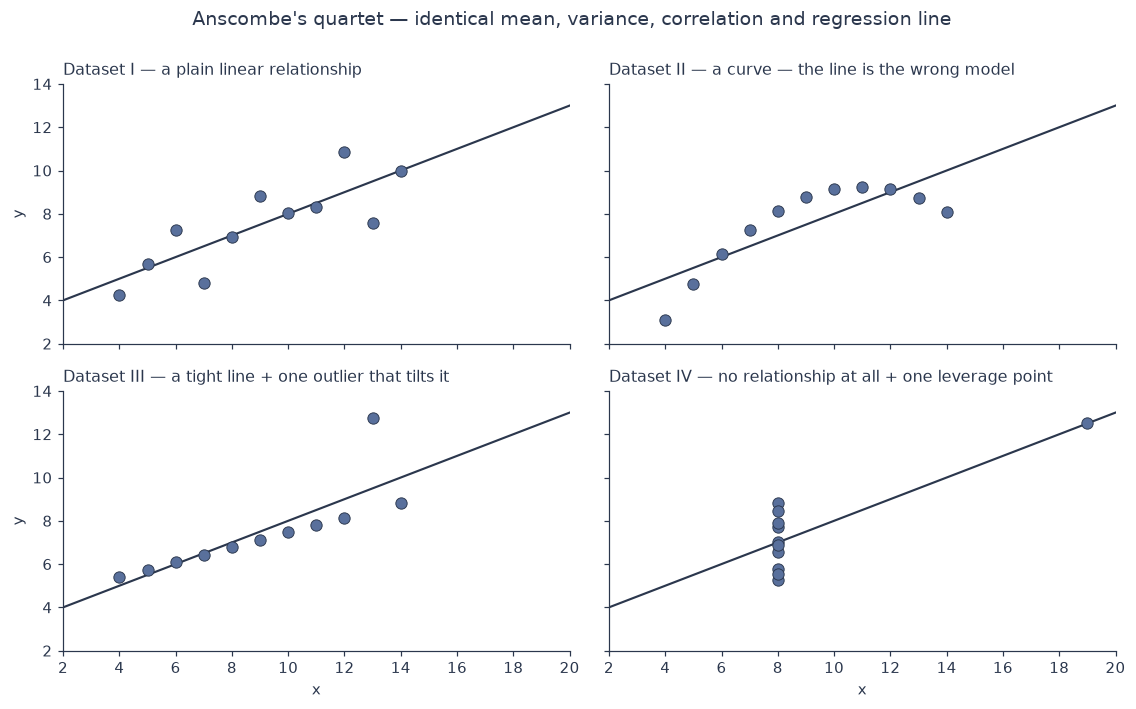

Same mean x (9.00), same mean y (7.50), same variance (4.123-4.128), same correlation (0.816-0.817),
same best-fit line (y = 3.00 + 0.50x) — and four different worlds.
[PASS] If summary statistics could tell you what your data looks like, these four would look alike.


In [20]:
# --- Task 2b, part two: THE REVEAL. Anscombe's quartet (F.J. Anscombe, 1973).
# --- Four datasets. One set of summary statistics. Run this only after MY_PREDICTION is filled in.
x_common = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
anscombe = {
    "I":   (x_common, np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II":  (x_common, np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (x_common, np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV":  (np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float),
            np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}
stories = {
    "I":   "a plain linear relationship",
    "II":  "a curve — the line is the wrong model",
    "III": "a tight line + one outlier that tilts it",
    "IV":  "no relationship at all + one leverage point",
}

rows = []
for name, (x, y) in anscombe.items():
    slope, intercept = np.polyfit(x, y, 1)
    rows.append({"dataset": name, "mean x": x.mean(), "mean y": y.mean(),
                 "variance y": y.var(ddof=1), "correlation": np.corrcoef(x, y)[0, 1],
                 "best-fit line": f"y = {intercept:.2f} + {slope:.2f}x"})
display(pd.DataFrame(rows).set_index("dataset").round(3))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 6.4), sharex=True, sharey=True)
line_x = np.array([2.0, 20.0])
for ax, (name, (x, y)) in zip(axes.ravel(), anscombe.items()):
    ax.plot(line_x, 3.0 + 0.5 * line_x, color=VSP["ink"], linewidth=1.4, zorder=1)
    ax.scatter(x, y, s=55, color=VSP["navy"], edgecolor=VSP["ink"], linewidth=0.6, zorder=2)
    ax.set_title(f"Dataset {name} — {stories[name]}", fontsize=10.5, loc="left")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
fig.suptitle("Anscombe's quartet — identical mean, variance, correlation and regression line",
             y=1.0, fontsize=12.5)
plt.tight_layout()
plt.show()

print("Same mean x (9.00), same mean y (7.50), same variance (4.123-4.128), same correlation (0.816-0.817),")
print("same best-fit line (y = 3.00 + 0.50x) — and four different worlds.")
print("[PASS] If summary statistics could tell you what your data looks like, these four would look alike.")

**Write one line on each:** what did the four identical summary statistics hide, and how close was
your prediction? Nobody grades the prediction. The habit it installs is the deliverable.

---

## Task 3 — the three questions, as an email *(15 min)*

Turn segment 4's drill into words you would actually send. Write the three questions as a short email to
the construction prospect's PM — client language, no jargon, and without the word *"accuracy"* doing any
unexamined work. ~150 words.

## Task 4 — apply it to your own number *(10 min)*

Take one real number from a project you are on right now — a latency SLO, a velocity average, a conversion
rate — and answer the session's two questions about it: **how many, and collected how?** Then name one
bias from segment 2's table of six that you cannot rule out. Three or four sentences.

## Task 5 — notebook extension *(10 min)*

Re-run the segment 2 sampling simulation against the **right-skewed latency population** instead of the
normal one. How large does *n* have to get before the sample mean settles within ±5 ms? Skew is why the
answer is bigger than you expect.

**Time accounting:** pre-work 30 min + homework 90 min (30 + 25 + 15 + 10 + 10) = 2 h out-of-session budget.

---

## Wrap-up

**You can now, on demand:**

- ask for the **shape** when someone hands you a mean, and say why p50/p90/p99 beats "average";
- ask **how many, and collected how** — and explain why 30,000 biased samples are worse than useless,
  because they come with false confidence;
- spot **variance as a promise-keeping risk**, not a statistics term;
- hear *"our model is 92% accurate"* and immediately ask the three questions: **on what data, what class
  balance, which mistakes.**

**Next — `LSN-0.3` Statistics II: probability, conditioning, correlation ≠ causation** (1 h live + 2 h out-of-session). Pre-work,
~30 min, and the rule still holds — **no pre-work, no seat**:

1. Watch 3Blue1Brown, *["The medical test paradox, and redesigning Bayes' rule"](https://www.youtube.com/watch?v=lG4VkPoG3ko)*
   (21 min) and bring one written answer: *a test catches 99%
   of cases — why isn't a positive result 99% proof you're sick?*
2. Fill in the base-rate fraud one-pager (`GAP-1` handout): a detector catching 99% of fraud, a 1%
   false-positive rate, fraud in 1 of 10,000 transactions — complete the counts table for 1,000,000
   transactions.

`LSN-0.3` is where today's "which mistakes make up the missing 8%?" gets its arithmetic, and `LSN-1.3` is
where it gets its vocabulary.